In [164]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [165]:
df=pd.read_csv(r"/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv")

In [166]:
df.sample()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8472,8473,15709621,Wan,662,France,Male,31,3,0.0,2,0,1,27731.05,0


In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

In [168]:
from sklearn.linear_model import Perceptron

In [169]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [170]:
df=df.drop(columns=['RowNumber','CustomerId','Surname'])

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [172]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [173]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [174]:
df.shape

(10000, 11)

In [175]:
df=pd.get_dummies(df,['Geography','Gender'],drop_first=True)
df.sample(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
7425,552,33,3,144962.74,1,1,0,58844.84,1,True,False,True
5763,724,32,6,0.00,2,1,1,150026.79,0,False,False,False
4275,536,32,7,178011.50,2,1,0,22375.14,0,False,False,True


In [176]:
X=df.drop(columns='Exited')
y=df['Exited']

In [177]:
from sklearn.model_selection import train_test_split


In [178]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=43)


In [179]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [180]:
X_train_trf=scaler.fit_transform(X_train)
X_test_trf=scaler.transform(X_test)

In [181]:
import tensorflow as tf
from tensorflow import keras


In [182]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [183]:
model = Sequential()
model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(22,activation='relu'))
model.add(Dense(22,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [184]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 22)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 22)             │           506 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            23 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 925 (3.61 KB)

 Trainable params: 925 (3.61 KB)

 Non-trainable params: 0 (0.00 B)

In [185]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [186]:
checkpoint = tf.keras.callbacks.ModelCheckpoint("optimal.weights.h5",verbose=1,save_best_only=True,save_weights_only = True)

In [187]:
history=model.fit(X_train_trf,y_train,callbacks=[checkpoint],batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
119/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6802 - loss: 0.5893
Epoch 1: val_loss improved from inf to 0.45999, saving model to optimal.weights.h5
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6869 - loss: 0.5841 - val_accuracy: 0.7994 - val_loss: 0.4600
Epoch 2/100
121/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7904 - loss: 0.4646
Epoch 2: val_loss improved from 0.45999 to 0.43247, saving model to optimal.weights.h5
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7908 - loss: 0.4634 - val_accuracy: 0.8075 - val_loss: 0.4325
Epoch 3/100
121/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8143 - loss: 0.4311
Epoch 3: val_loss improved from 0.43247 to 0.42349, saving model to optimal.weights.h5
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8143 - loss: 0.4309 - val_accuracy: 0.8125 - val_loss: 0.4235
Epoch 4/100
119/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8147 - loss: 0.4187
Epoch 4: val_loss improved from 0.42349 to 0

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

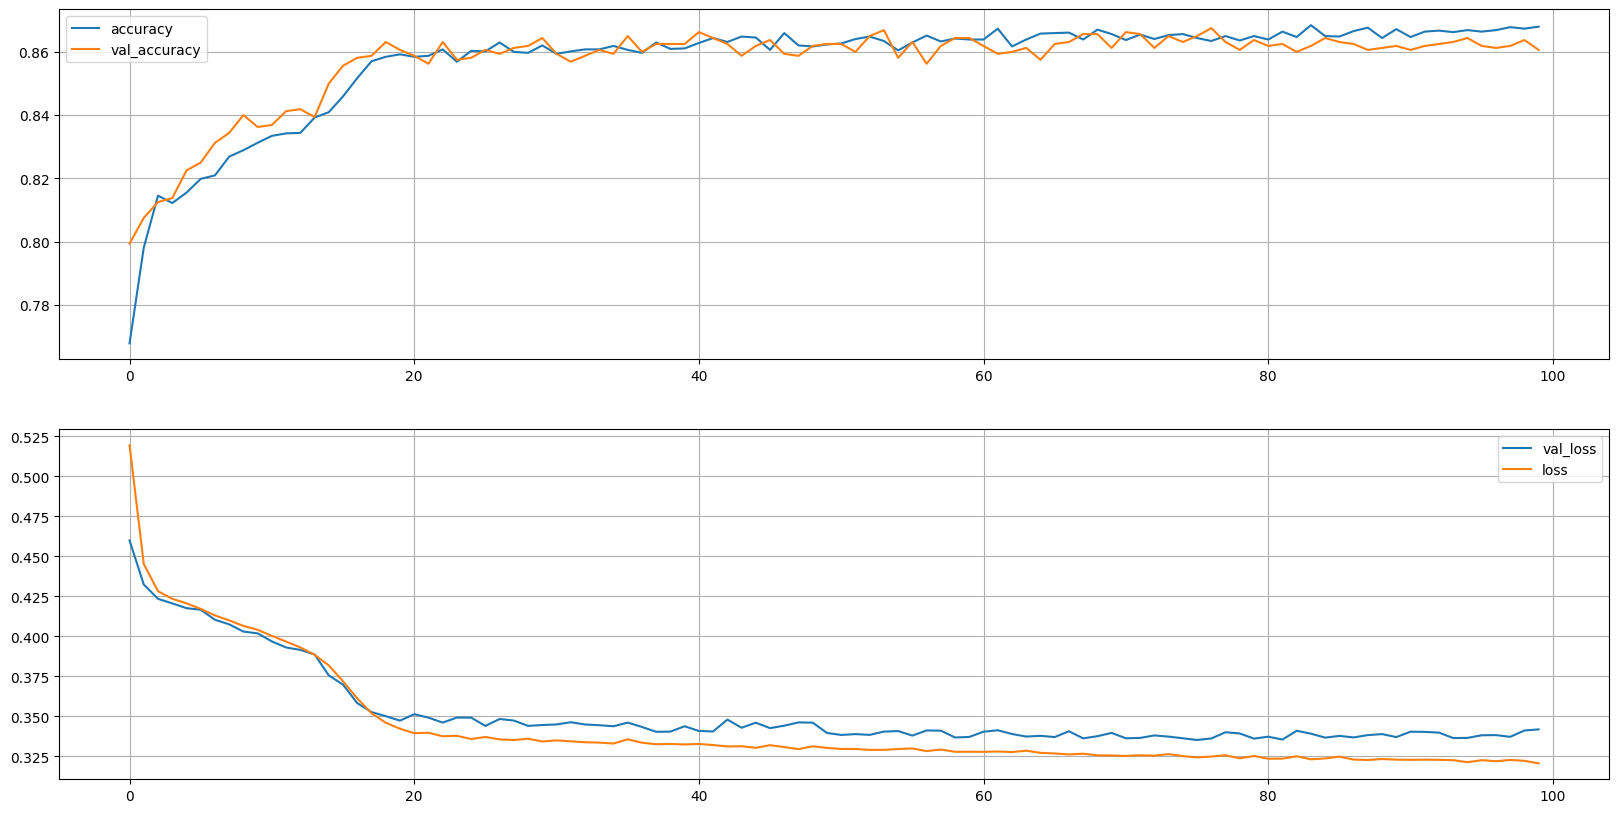

In [188]:
plt.figure(figsize=(20,10))
x=[i for i in range(len(history.history['accuracy']))]
y=history.history['accuracy']
yy=history.history['loss']
yyy=history.history['val_accuracy']
yyyy=history.history['val_loss']
plt.subplot(2,1,1)
sns.lineplot(x=x,y=y,label='accuracy')
sns.lineplot(x=x,y=yyy,label='val_accuracy')
plt.legend()
plt.grid()
plt.subplot(2,1,2)
sns.lineplot(x=x,y=yyyy,label='val_loss')
sns.lineplot(x=x,y=yy,label='loss')
plt.legend()
plt.grid()
plt.show()


In [189]:
y_pred= model.predict(X_test_trf)
model.load_weights('optimal.weights.h5')
best_y_pred=model.predict(X_test_trf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [190]:
y_pred=y_pred.argmax(axis=-1)
best_y_pred=best_y_pred.argmax(axis=-1)

In [191]:
from sklearn.metrics import accuracy_score

In [192]:
print('model acc: ',accuracy_score(y_test,y_pred))
print('best model acc: ',accuracy_score(y_test,best_y_pred))

model acc:  0.794
best model acc:  0.794
